# Week 4：LSTM 门控机制学习笔记

- 作者：王雷
- 日期：2026-07-24
- 适用周次：Week 3 方向专题分享 / Week 4 RNN → Transformer → BERT
- 分类：06-nlp
- 关键词：RNN、LSTM、gate、长程依赖、文本分类、SwiGLU

## 学习目标

1. 用公式和代码理解 LSTM 的输入门、遗忘门、候选记忆和输出门。
2. 手写一个最小可运行的 LSTM Cell，而不是只调用 nn.LSTM。
3. 在一个合成文本分类任务中观察 LSTM 如何处理 not ... good/bad 这类长程否定关系。
4. 可视化训练后不同 gate 在 token 序列上的响应。
5. 连接到现代大模型中的 GLU / SwiGLU，理解门控思想为什么仍然重要。

## 运行说明

- 不下载外部数据。
- 不依赖本地绝对路径。
- 建议内核：torch。
- 主要依赖：Python、PyTorch、NumPy、Matplotlib。

In [1]:
import math
import random
import platform
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

SEED = 20260724
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cpu")
print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("Device:", device)

Python: 3.10.15
PyTorch: 2.0.0+cpu
Device: cpu


## 1. 从普通 RNN 到 LSTM

普通 RNN 可以写成：

\[
h_t = \tanh(W_x x_t + W_h h_{t-1} + b)
\]

问题在于：它每一步都用新的隐藏状态覆盖旧隐藏状态。如果重要信息出现在很早的位置，比如 not ... good 中的 not，模型要把这个信息一路传到后面。反向传播时梯度会反复经过递归矩阵和非线性函数，容易衰减或爆炸。

LSTM 增加了 cell state \(c_t\)，让信息可以沿着一条更稳定的路径传播，并用 gate 控制写入、保留和读取。

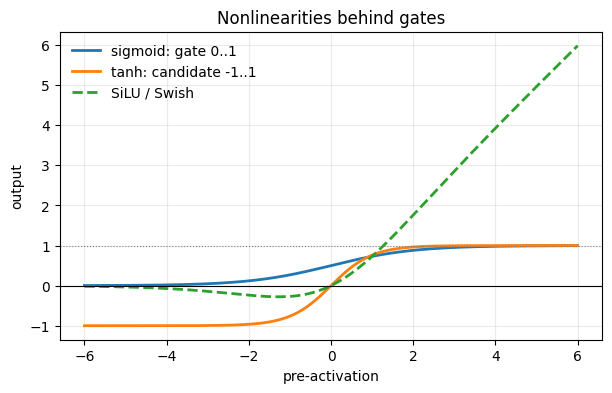

In [2]:
x = torch.linspace(-6, 6, 400)
sigmoid = torch.sigmoid(x)
tanh = torch.tanh(x)
silu = F.silu(x)

plt.figure(figsize=(7, 4))
plt.plot(x, sigmoid, label="sigmoid: gate 0..1", linewidth=2)
plt.plot(x, tanh, label="tanh: candidate -1..1", linewidth=2)
plt.plot(x, silu, label="SiLU / Swish", linewidth=2, linestyle="--")
plt.axhline(0, color="black", linewidth=0.8)
plt.axhline(1, color="gray", linewidth=0.8, linestyle=":")
plt.title("Nonlinearities behind gates")
plt.xlabel("pre-activation")
plt.ylabel("output")
plt.grid(alpha=0.25)
plt.legend(frameon=False)
plt.show()

## 2. LSTM 的门控公式

LSTM 一步的更新通常写成：

\[
\begin{aligned}
i_t &= \sigma(W_i [x_t; h_{t-1}] + b_i) \\
f_t &= \sigma(W_f [x_t; h_{t-1}] + b_f) \\
g_t &= \tanh(W_g [x_t; h_{t-1}] + b_g) \\
o_t &= \sigma(W_o [x_t; h_{t-1}] + b_o) \\
c_t &= f_t \odot c_{t-1} + i_t \odot g_t \\
h_t &= o_t \odot \tanh(c_t)
\end{aligned}
\]

其中：

- \(i_t\)：输入门，决定新信息写入多少。
- \(f_t\)：遗忘门，决定旧记忆保留多少。
- \(g_t\)：候选记忆，生成准备写入的新内容。
- \(o_t\)：输出门，决定当前记忆暴露给下游多少。

In [3]:
class ManualLSTMCell(nn.Module):
    """A minimal LSTM cell written from the equations above."""
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.gates = nn.Linear(input_size + hidden_size, 4 * hidden_size)

        # Positive forget bias makes the model initially less eager to erase memory.
        with torch.no_grad():
            self.gates.bias[hidden_size:2 * hidden_size].fill_(1.0)

    def forward(self, x_t, state):
        h_prev, c_prev = state
        combined = torch.cat([x_t, h_prev], dim=-1)
        i_raw, f_raw, g_raw, o_raw = self.gates(combined).chunk(4, dim=-1)

        i_t = torch.sigmoid(i_raw)
        f_t = torch.sigmoid(f_raw)
        g_t = torch.tanh(g_raw)
        o_t = torch.sigmoid(o_raw)

        c_t = f_t * c_prev + i_t * g_t
        h_t = o_t * torch.tanh(c_t)

        gates = {"input": i_t, "forget": f_t, "candidate": g_t, "output": o_t}
        return h_t, c_t, gates

In [4]:
batch_size, input_size, hidden_size = 3, 5, 4
cell = ManualLSTMCell(input_size=input_size, hidden_size=hidden_size)

x_t = torch.randn(batch_size, input_size)
h0 = torch.zeros(batch_size, hidden_size)
c0 = torch.zeros(batch_size, hidden_size)

h1, c1, gates = cell(x_t, (h0, c0))

print("x_t:", tuple(x_t.shape))
print("h1:", tuple(h1.shape))
print("c1:", tuple(c1.shape))
for name, value in gates.items():
    print(f"{name:9s}", tuple(value.shape), "mean=", round(value.mean().item(), 3))

x_t: (3, 5)
h1: (3, 4)
c1: (3, 4)
input     (3, 4) mean= 0.528
forget    (3, 4) mean= 0.73
candidate (3, 4) mean= -0.096
output    (3, 4) mean= 0.476


## 3. 遗忘门的直觉：不是永远记住，而是动态保留

如果某个维度上的遗忘门近似为常数 \(f\)，经过 \(t\) 步后旧记忆大约剩下 \(f^t\)。这不是严格训练公式，但很适合理解为什么遗忘门重要。

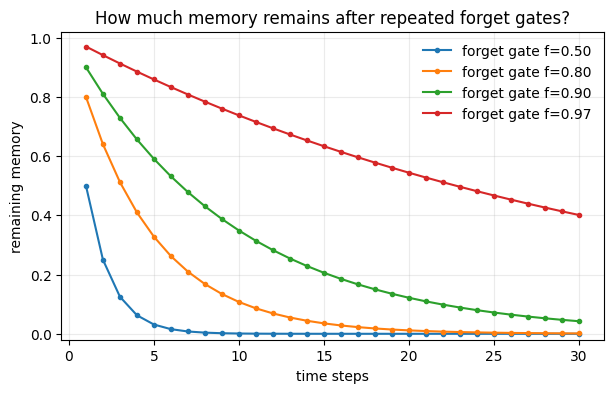

In [5]:
steps = torch.arange(1, 31)
plt.figure(figsize=(7, 4))
for f in [0.50, 0.80, 0.90, 0.97]:
    plt.plot(steps, f ** steps, marker="o", markersize=3, label=f"forget gate f={f:.2f}")
plt.title("How much memory remains after repeated forget gates?")
plt.xlabel("time steps")
plt.ylabel("remaining memory")
plt.ylim(-0.02, 1.02)
plt.grid(alpha=0.25)
plt.legend(frameon=False)
plt.show()

## 4. 构造一个小型文本分类任务

为了让 LSTM 的序列记忆有用，我们构造一个含有长程否定关系的小任务：

- good / excellent 通常是正类。
- bad / boring / terrible 通常是负类。
- 如果前面出现 not，极性反转：not ... good 是负类，not ... bad 是正类。
- not 和情感词之间会插入若干 filler token，制造长程依赖。

这个数据是合成的，只用于理解机制，不代表真实 NLP benchmark。

In [6]:
PAD = "<pad>"
VOCAB = [
    PAD, "this", "movie", "story", "plot", "is", "really", "very", "quite",
    "not", "good", "bad", "boring", "excellent", "terrible", "today",
]
stoi = {token: idx for idx, token in enumerate(VOCAB)}
itos = {idx: token for token, idx in stoi.items()}

positive_words = ["good", "excellent"]
negative_words = ["bad", "boring", "terrible"]
fillers = ["this", "movie", "story", "plot", "is", "really", "very", "quite", "today"]

def make_example(max_gap=7):
    has_negation = random.random() < 0.45
    if random.random() < 0.5:
        sentiment_word = random.choice(positive_words)
        base_label = 1
    else:
        sentiment_word = random.choice(negative_words)
        base_label = 0

    gap = random.randint(1, max_gap)
    middle = random.choices(fillers, k=gap)

    if has_negation:
        tokens = random.choices(fillers, k=random.randint(0, 2)) + ["not"] + middle + [sentiment_word]
        label = 1 - base_label
    else:
        tokens = random.choices(fillers, k=random.randint(1, 4)) + middle + [sentiment_word]
        label = base_label

    return tokens[:14], label

def encode(tokens):
    return [stoi[t] for t in tokens]

def build_dataset(n):
    return [make_example() for _ in range(n)]

train_data = build_dataset(900)
valid_data = build_dataset(240)

for tokens, label in train_data[:6]:
    print(" ".join(tokens), "=>", "positive" if label else "negative")

movie is quite today really terrible => negative
not movie very plot boring => positive
story plot very movie really this quite this excellent => positive
plot really this today plot really quite story boring => negative
this this plot plot really this this really excellent => positive
not is excellent => negative


In [7]:
def collate(batch):
    lengths = torch.tensor([len(tokens) for tokens, _ in batch], dtype=torch.long)
    max_len = int(lengths.max())
    input_ids = torch.full((len(batch), max_len), stoi[PAD], dtype=torch.long)
    labels = torch.tensor([label for _, label in batch], dtype=torch.long)

    for row, (tokens, _) in enumerate(batch):
        ids = encode(tokens)
        input_ids[row, :len(ids)] = torch.tensor(ids, dtype=torch.long)

    return input_ids.to(device), lengths.to(device), labels.to(device)

def iterate_minibatches(data, batch_size=32, shuffle=True):
    indices = list(range(len(data)))
    if shuffle:
        random.shuffle(indices)
    for start in range(0, len(indices), batch_size):
        yield collate([data[i] for i in indices[start:start + batch_size]])

batch_ids, batch_lengths, batch_labels = next(iterate_minibatches(train_data, batch_size=4))
print("input_ids shape:", tuple(batch_ids.shape))
print("lengths:", batch_lengths.tolist())
print("labels:", batch_labels.tolist())
print("first decoded:", [itos[int(i)] for i in batch_ids[0, :batch_lengths[0]].tolist()])

input_ids shape: (4, 8)
lengths: [8, 3, 8, 5]
labels: [1, 0, 1, 0]
first decoded: ['not', 'movie', 'plot', 'very', 'is', 'really', 'story', 'boring']


## 5. 训练一个可检查 gate 的 LSTM 分类器

这里不用 nn.LSTM，而是把上面的 ManualLSTMCell 循环起来，这样训练后可以拿到每个 token 的输入门、遗忘门、输出门数值。

In [8]:
class InspectableLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=24, hidden_size=32, num_classes=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=stoi[PAD])
        self.cell = ManualLSTMCell(embed_dim, hidden_size)
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, input_ids, lengths, collect_gates=False):
        batch_size, seq_len = input_ids.shape
        hidden_size = self.cell.hidden_size

        embedded = self.embedding(input_ids)
        h_t = torch.zeros(batch_size, hidden_size, device=input_ids.device)
        c_t = torch.zeros(batch_size, hidden_size, device=input_ids.device)
        gate_history = []

        for t in range(seq_len):
            new_h, new_c, gates = self.cell(embedded[:, t], (h_t, c_t))
            mask = (t < lengths).float().unsqueeze(-1)
            h_t = mask * new_h + (1.0 - mask) * h_t
            c_t = mask * new_c + (1.0 - mask) * c_t

            if collect_gates:
                gate_history.append({name: value.detach().cpu() for name, value in gates.items()})

        logits = self.classifier(h_t)
        if collect_gates:
            return logits, gate_history
        return logits

model = InspectableLSTMClassifier(vocab_size=len(VOCAB)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

def evaluate(model, data):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0.0
    with torch.no_grad():
        for input_ids, lengths, labels in iterate_minibatches(data, batch_size=64, shuffle=False):
            logits = model(input_ids, lengths)
            loss = criterion(logits, labels)
            total_loss += loss.item() * labels.numel()
            pred = logits.argmax(dim=-1)
            correct += int((pred == labels).sum())
            total += labels.numel()
    return total_loss / total, correct / total

history = []
for epoch in range(1, 9):
    model.train()
    for input_ids, lengths, labels in iterate_minibatches(train_data, batch_size=32, shuffle=True):
        optimizer.zero_grad()
        logits = model(input_ids, lengths)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        optimizer.step()

    train_loss, train_acc = evaluate(model, train_data)
    valid_loss, valid_acc = evaluate(model, valid_data)
    history.append((epoch, train_loss, train_acc, valid_loss, valid_acc))
    print(
        f"epoch {epoch:02d} | train acc {train_acc:.3f} | "
        f"valid acc {valid_acc:.3f} | valid loss {valid_loss:.3f}"
    )

epoch 01 | train acc 0.993 | valid acc 0.996 | valid loss 0.171
epoch 02 | train acc 1.000 | valid acc 1.000 | valid loss 0.002
epoch 03 | train acc 1.000 | valid acc 1.000 | valid loss 0.001
epoch 04 | train acc 1.000 | valid acc 1.000 | valid loss 0.001
epoch 05 | train acc 1.000 | valid acc 1.000 | valid loss 0.001
epoch 06 | train acc 1.000 | valid acc 1.000 | valid loss 0.001
epoch 07 | train acc 1.000 | valid acc 1.000 | valid loss 0.001
epoch 08 | train acc 1.000 | valid acc 1.000 | valid loss 0.001


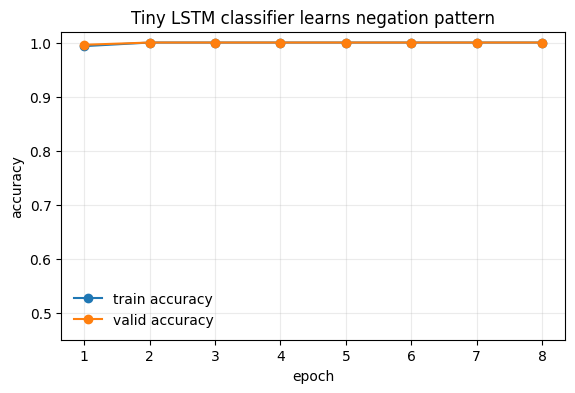

In [9]:
epochs = [row[0] for row in history]
train_acc = [row[2] for row in history]
valid_acc = [row[4] for row in history]

plt.figure(figsize=(6.5, 4))
plt.plot(epochs, train_acc, marker="o", label="train accuracy")
plt.plot(epochs, valid_acc, marker="o", label="valid accuracy")
plt.title("Tiny LSTM classifier learns negation pattern")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.ylim(0.45, 1.02)
plt.grid(alpha=0.25)
plt.legend(frameon=False)
plt.show()

## 6. 看训练后的 gate heatmap

下面选择一个带 not 的样本，观察不同 gate 在每个 token 上的平均响应。由于 hidden size 有多个维度，这里对 hidden 维度取平均，只做直观展示。

需要注意：gate heatmap 不是严格的可解释性证据，它只能帮助我们检查模型是否在关键 token 附近产生了明显控制信号。

sentence: this movie is not really very quite good
P(negative), P(positive): [0.9984, 0.0016]


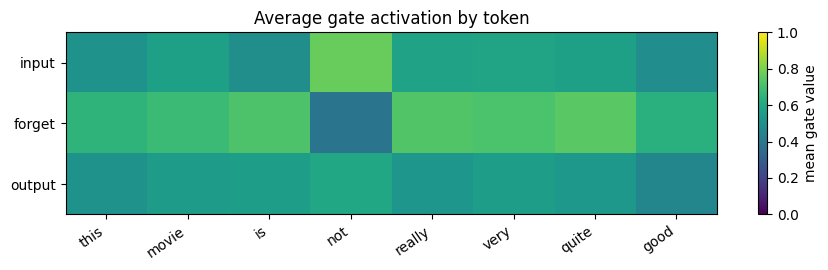

In [10]:
def predict_one(tokens):
    batch = [(tokens, 0)]
    input_ids, lengths, _ = collate(batch)
    model.eval()
    with torch.no_grad():
        logits, gate_history = model(input_ids, lengths, collect_gates=True)
        probs = logits.softmax(dim=-1).squeeze(0)
    return probs.cpu(), gate_history, int(lengths.item())

probe_tokens = ["this", "movie", "is", "not", "really", "very", "quite", "good"]
probs, gate_history, length = predict_one(probe_tokens)

print("sentence:", " ".join(probe_tokens))
print("P(negative), P(positive):", [round(float(p), 4) for p in probs])

gate_names = ["input", "forget", "output"]
heatmap = []
for name in gate_names:
    values = []
    for t in range(length):
        values.append(gate_history[t][name][0].mean().item())
    heatmap.append(values)

plt.figure(figsize=(9, 2.8))
plt.imshow(heatmap, aspect="auto", cmap="viridis", vmin=0, vmax=1)
plt.yticks(range(len(gate_names)), gate_names)
plt.xticks(range(length), probe_tokens, rotation=35, ha="right")
plt.colorbar(label="mean gate value")
plt.title("Average gate activation by token")
plt.tight_layout()
plt.show()

## 7. 和 PyTorch nn.LSTM 的接口对齐

真实项目中通常直接用 nn.LSTM，因为它更快、实现更稳定。手写 Cell 的目的不是替代官方实现，而是帮助理解官方模块内部在做什么。

In [11]:
official_lstm = nn.LSTM(
    input_size=12,
    hidden_size=16,
    num_layers=1,
    batch_first=True,
    bidirectional=True,
)

toy_x = torch.randn(4, 7, 12)
output, (h_n, c_n) = official_lstm(toy_x)

print("input:", tuple(toy_x.shape))
print("output:", tuple(output.shape), "  # batch, seq_len, hidden*directions")
print("h_n:", tuple(h_n.shape), "      # layers*directions, batch, hidden")
print("c_n:", tuple(c_n.shape), "      # layers*directions, batch, hidden")

input: (4, 7, 12)
output: (4, 7, 32)   # batch, seq_len, hidden*directions
h_n: (2, 4, 16)       # layers*directions, batch, hidden
c_n: (2, 4, 16)       # layers*directions, batch, hidden


## 8. 大模型时代的门控：从 LSTM 到 GLU / SwiGLU

LSTM 的 gate 控制的是时间步之间的记忆流。Transformer 的注意力主要控制 token 之间读什么信息，而现代语言模型前馈层里的 GLU / SwiGLU 控制的是 hidden channel 之间哪些特征通过。

GLU/SwiGLU 的形式可以简化理解为：

\[
\mathrm{GLU}(x) = (xW_a) \odot \sigma(xW_b)
\]

\[
\mathrm{SwiGLU}(x) = (xW_a) \odot \mathrm{SiLU}(xW_b)
\]

直觉仍然是：一条分支产生内容，另一条分支产生控制信号，然后逐元素相乘。

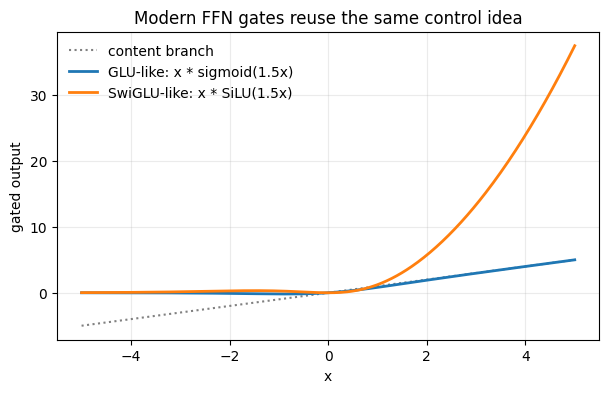

In [12]:
x = torch.linspace(-5, 5, 400)
content = x
glu_gate = torch.sigmoid(1.5 * x)
swiglu_gate = F.silu(1.5 * x)

glu_out = content * glu_gate
swiglu_out = content * swiglu_gate

plt.figure(figsize=(7, 4))
plt.plot(x, content, label="content branch", color="gray", linestyle=":")
plt.plot(x, glu_out, label="GLU-like: x * sigmoid(1.5x)", linewidth=2)
plt.plot(x, swiglu_out, label="SwiGLU-like: x * SiLU(1.5x)", linewidth=2)
plt.title("Modern FFN gates reuse the same control idea")
plt.xlabel("x")
plt.ylabel("gated output")
plt.grid(alpha=0.25)
plt.legend(frameon=False)
plt.show()

## 9. 小结

- LSTM 的核心不是“多了几个公式”，而是把序列状态拆成可写入、可保留、可读取的记忆系统。
- 输入门、遗忘门、输出门都是 sigmoid gate；候选记忆用 tanh 生成待写入内容。
- 遗忘门提供一条更稳定的 memory path，因此比普通 RNN 更适合处理一定范围内的长程依赖。
- 手写 LSTM Cell 能帮助理解 PyTorch nn.LSTM 的内部逻辑，但真实项目一般直接使用官方实现。
- Transformer 成为主流后，LSTM 的递归结构不再是大模型主干；但“门控控制信息流”的思想仍然出现在 GLU、SwiGLU、MoE routing 等模块中。

## 9. 参考资料

- Hochreiter, S. and Schmidhuber, J. (1997). Long Short-Term Memory. Neural Computation. DOI: https://doi.org/10.1162/neco.1997.9.8.1735
- PyTorch documentation: torch.nn.LSTM. https://docs.pytorch.org/docs/stable/generated/torch.nn.LSTM.html
- Stanford CS224n: Natural Language Processing with Deep Learning. https://web.stanford.edu/class/cs224n/
- Christopher Olah, Understanding LSTM Networks. https://colah.github.io/posts/2015-08-Understanding-LSTMs/
- Shazeer (2020). GLU Variants Improve Transformer. https://arxiv.org/abs/2002.05202
- PaLM technical report, showing SwiGLU-style gated feed-forward usage in large language models. https://arxiv.org/abs/2204.02311
- LLaMA paper, describing gated feed-forward layers with SwiGLU. https://arxiv.org/abs/2302.13971